# Crack-Spread — a quantitative teardown
### Real daily tape · predictive vs coincident regression · excess-vs-excess timer race · cost sweep · synthetic lead-lag control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident_%E2%89%A0_predictive%3F: Confirmed](https://img.shields.io/badge/Coincident_%E2%89%A0_predictive%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We isolate the predictive content of the 3-2-1 crack for an equal-weight refiner basket, race two crack-timers against always-long buy-and-hold on the **active** return, and confirm with a synthetic lead-lag control that our null is the market's, not the harness's.

> **Not investment advice.** Real data: Yahoo daily futures + equities, 2012-04 to 2026-05 (partial June 2026 dropped); as-of 2026-06-17; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crack_spread import data, strategy as st

AS_OF_CUTOFF = "2026-06-01"   # drop the partial June 2026 month

def _have_cache():
    return os.path.exists(data._cache_path("CL=F", data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def real_tape():
    f = data.load_real(fetch=False)
    return f[f.index < AS_OF_CUTOFF]

print("real crack/refiner cache present:", HAVE_REAL)


real crack/refiner cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Lagged crack→basket slope HAC *t* = **-0.51** (R² ≈ 0.0001), unstable across halves (pre +1.72, post -1.24). Only the *same-day* relation is significant (*t* = +2.06, R² = 0.021) — unforecastable. |
| **Tradability** | `MIRAGE` | No timer beats B&H on active return: level -1.92%/yr (*t* -0.25), 20-day momentum -0.27%/yr (*t* -0.04); negative at any cost. Timer Sharpe CI [0.19, 1.38] inside B&H's. |
| **Coincident ≠ predictive?** | `CONFIRMED` | Same-day *t* = +2.06 vs predictive *t* = -0.51: a textbook zero-lag confound. |

> In plain words: the crack spread is the refiner's margin expressed in market prices, so it co-moves with the equity contemporaneously and forecasts nothing — and a part-time-in-cash crack-timer's flattering Sharpe is cash drag, not alpha.

## 1 · The claim, steelmanned

Let $c_t$ be the 3-2-1 crack level and $r_t$ the basket's daily log return. The tradable hypothesis is **predictive**:

$$r_t = \alpha + \beta\,\Delta c_{t-1} + \varepsilon_t, \qquad H_1: \beta \neq 0$$

- **H₁ (predictive signal).** Yesterday's crack change forecasts today's return.
- **H₂ (tradable timer).** A crack-conditioned timer beats always-long B&H on the *active* return (timer − B&H), net of costs.
- **H₃ (it's not just the mirror).** The lagged effect is distinct from the trivially large *contemporaneous* slope $\Delta c_t \to r_t$.

We find **H₁ rejected**, **H₂ rejected**, and **H₃ is the whole point**: only the contemporaneous slope is real, and it is not tradable.

## 2 · So what? — what rides on each answer

A public, intraday-observable margin that *led* a whole sub-sector would be a genuine, scalable timing tool. The interesting content is not the binary verdict (markets are efficient in liquid large-caps — few will be shocked) but the **mechanism**: the crack is, by accounting identity, the revenue-minus-input line of the business, so a same-day correlation is guaranteed and uninformative for timing. Naming that confound precisely is worth more than the stamp.

## 3 · How we'd know — the protocol

- **Signal.** OLS of $r_t$ on standardised $\Delta c_{t-1}$ (predictive) and $\Delta c_t$ (coincident foil); **Newey-West HAC** *t* on each slope.
- **Timers.** `level` (crack > trailing-252 median) and `momentum` (crack rose over the lookback); 0/1 positions, **one execution lag** (signal at close $t$ → return $t{+}1$), costs **one-way × NAV** on each switch.
- **Race.** Excess-vs-excess: the **active return** (timer − buy-and-hold) and its HAC *t*; a part-time-in-cash timer's raw Sharpe is not a fair comparison.
- **Inference.** Circular block-bootstrap (21-day) Sharpe CIs; pre/post split.
- **Positive control.** Deterministic synthetic tape with a tunable `lead` — the crack co-moves same-day regardless, and *predicts* only when a lead is planted.

Tape: 3-2-1 crack (RB=F, HO=F, CL=F) vs equal-weight TR basket (VLO, MPC, PSX), daily 2012–2026.

## 4 · The teardown

### 4a · Predictive vs coincident — the zero-lag confound

The same regressor (the crack change) at lag 1 (predictive) and lag 0 (coincident).

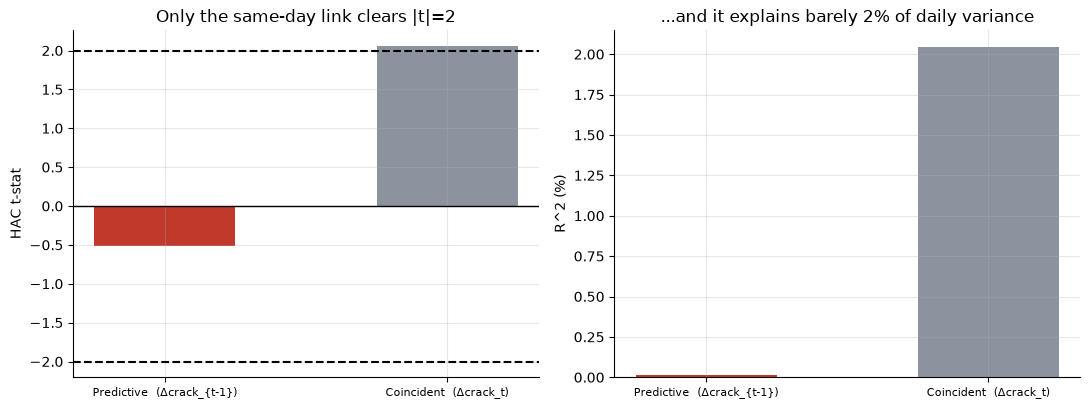

                  relation    slope        t      r2
Predictive  (Δcrack_{t-1}) -0.00024 -0.51088 0.00012
    Coincident  (Δcrack_t)  0.00311  2.05690 0.02045


In [2]:
if HAVE_REAL:
    f = real_tape()
    pred = st.predictive_regression(f); coin = st.contemporaneous_regression(f)
    rows = [('Predictive  (Δcrack_{t-1})', pred['slope'], pred['tstat'], pred['r2']),
            ('Coincident  (Δcrack_t)',     coin['slope'], coin['tstat'], coin['r2'])]
else:
    rows = [('Predictive  (Δcrack_{t-1})', -0.00024, -0.51, 0.0001),
            ('Coincident  (Δcrack_t)',     0.00311, 2.06, 0.0205)]
dfr = pd.DataFrame(rows, columns=['relation','slope','t','r2'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(dfr['relation'], dfr['t'], color=[RED, GREY], width=.5)
a1.axhline(2, ls='--', c='k'); a1.axhline(-2, ls='--', c='k'); a1.axhline(0, c='k', lw=1)
a1.set_ylabel('HAC t-stat'); a1.set_title('Only the same-day link clears |t|=2')
a1.tick_params(axis='x', labelsize=8)
a2.bar(dfr['relation'], dfr['r2']*100, color=[RED, GREY], width=.5)
a2.set_ylabel('R^2 (%)'); a2.set_title('...and it explains barely 2% of daily variance')
a2.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
print(dfr.round(5).to_string(index=False))

> 💡 In plain words: the predictive slope's HAC *t* is **-0.51** — economic and statistical zero. The coincident slope is significant (*t* = +2.06) but tiny in R² and untradeable. **H₁ rejected, H₃ confirmed**: the 'signal' is the mirror. The predictive slope also flips sign across halves (pre +1.72, post -1.24) — the signature of noise, not a decaying real effect.

### 4b · The timer race — excess vs excess

Two crack-timers vs always-long buy-and-hold, judged on the **active return** so the cash-drag does not flatter the verdict.

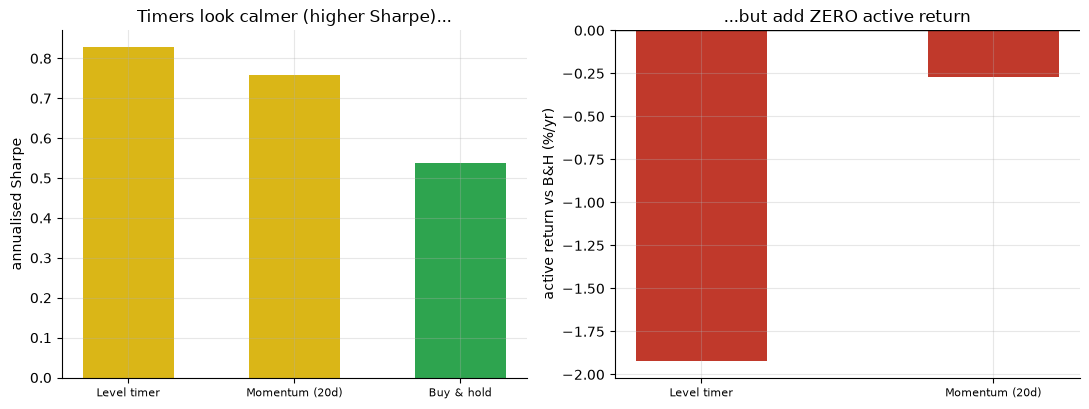

         timer  timer_sharpe  active_ann  active_t   pim
   Level timer          0.83       -1.92     -0.25 45.03
Momentum (20d)          0.76       -0.27     -0.04 49.93


In [3]:
if HAVE_REAL:
    f = real_tape()
    lvl = st.summarize_timer(f, st.level_signal(f['crack']))
    mom = st.summarize_timer(f, st.momentum_signal(f['crack'], 20))
    bh_sh = lvl['bh_sharpe']
    rows = [('Level timer', lvl['timer_sharpe'], lvl['active_ann'], lvl['active_t'], lvl['pct_in_market']),
            ('Momentum (20d)', mom['timer_sharpe'], mom['active_ann'], mom['active_t'], mom['pct_in_market'])]
else:
    bh_sh = 0.54
    rows = [('Level timer', 0.83, -1.92, -0.25, 45),
            ('Momentum (20d)', 0.76, -0.27, -0.04, 50)]
dft = pd.DataFrame(rows, columns=['timer','timer_sharpe','active_ann','active_t','pim'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(list(dft['timer'])+['Buy & hold'], list(dft['timer_sharpe'])+[bh_sh],
       color=[AMBER, AMBER, GREEN], width=.55)
a1.set_ylabel('annualised Sharpe'); a1.set_title('Timers look calmer (higher Sharpe)...')
a1.tick_params(axis='x', labelsize=8)
a2.bar(dft['timer'], dft['active_ann'], color=RED, width=.45)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('active return vs B&H (%/yr)')
a2.set_title('...but add ZERO active return'); a2.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
print(dft.round(2).to_string(index=False))

> 💡 In plain words: the timers post a *higher* Sharpe than B&H (0.83/0.76 vs 0.54) purely because they sit in cash ~50% of the time — lower vol, not more return. On the honest metric, the **active return is ~0 and insignificant** (-0.27%/yr, *t* = -0.04). **H₂ rejected.** The raw-Sharpe-vs-excess-Sharpe trap is exactly what METHODOLOGY warns about.

## 5 · The verdict

- **Signal `NONE`** — lagged crack→basket HAC *t* = -0.51, R² ≈ 0.0001, sign-flipping across halves. The only real link is contemporaneous (*t* = +2.06), which cannot be traded.
- **Tradability `MIRAGE`** — no timer beats B&H on active return (best gross +1.74%/yr at *t* = +0.27); negative at any cost; timer Sharpe CI [0.19, 1.38] sits inside B&H's [-0.02, 1.13].
- **Coincident ≠ predictive `CONFIRMED`** — the crack is the margin in real time; the same-day correlation is an accounting identity, not a forecast.

## 6 · Could you trade it? — cost sweep

There is no gross edge to defend, so the cost sweep only confirms the obvious.

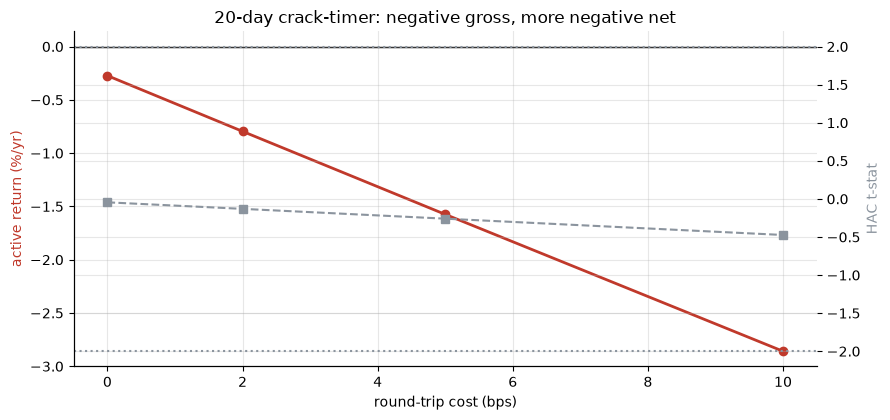

At 10 bps: active -2.86%/yr, t=-0.47


In [4]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    f = real_tape(); pos = st.momentum_signal(f['crack'], 20)
    act = [st.summarize_timer(f, pos, cost_bps=c)['active_ann'] for c in costs]
    tt = [st.summarize_timer(f, pos, cost_bps=c)['active_t'] for c in costs]
else:
    act = [-0.27, -0.8, -1.57, -2.86]
    tt = [-0.04, -0.13, -0.26, -0.47]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, act, 'o-', c=RED, lw=2, label='active return (%/yr)')
ax2 = ax.twinx(); ax2.plot(costs, tt, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('active return (%/yr)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('20-day crack-timer: negative gross, more negative net')
plt.tight_layout(); plt.show()
print(f'At 10 bps: active -2.86%/yr, t=-0.47')

> 💡 In plain words: contrast the desk's *fragile* signals, which start positive gross and erode under costs. Here the active return is already -0.27%/yr gross and only worsens — a mirage from the first dollar, not an edge that costs ate.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful lead-lag detector, or does it always print null? Plant a true predictive lead and confirm both the regression and the timer light up — while a zero-lead tape still shows the same-day mirror but no predictability.

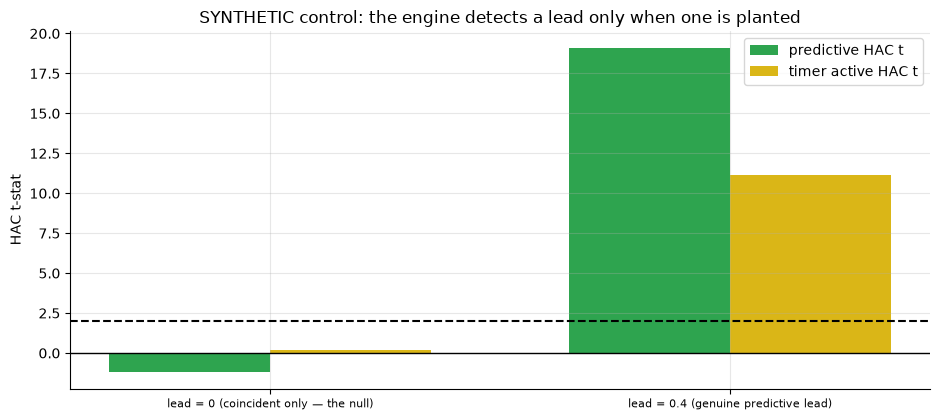

[SYNTHETIC tape — not the market]
                       synthetic tape  pred_t  timer_active  active_t
lead = 0 (coincident only — the null)   -1.21          1.15      0.19
 lead = 0.4 (genuine predictive lead)   19.12        109.36     11.13


In [5]:
rows = []
for lead, lab in [(0.0, 'lead = 0 (coincident only — the null)'),
                  (0.4, 'lead = 0.4 (genuine predictive lead)')]:
    f, _ = data.synthetic_tape(n_days=4000, lead=lead, seed=306)
    pr = st.predictive_regression(f)
    s = st.summarize_timer(f, st.momentum_signal(f['crack'], 1))
    rows.append((lab, pr['tstat'], s['active_ann'], s['active_t']))
dfs = pd.DataFrame(rows, columns=['synthetic tape','pred_t','timer_active','active_t'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(len(dfs)); w = .35
ax.bar(x-w/2, dfs['pred_t'], w, color=GREEN, label='predictive HAC t')
ax.bar(x+w/2, dfs['active_t'], w, color=AMBER, label='timer active HAC t')
ax.axhline(2, ls='--', c='k'); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(dfs['synthetic tape'], fontsize=8)
ax.set_ylabel('HAC t-stat'); ax.legend()
ax.set_title('SYNTHETIC control: the engine detects a lead only when one is planted')
plt.tight_layout(); plt.show()
print('[SYNTHETIC tape — not the market]')
print(dfs.round(2).to_string(index=False))

> 💡 In plain words (synthetic, not the market): at lead = 0 the predictive *t* is ~-1.3 and the timer adds nothing (*t* = +0.28) — exactly the real-tape picture. Plant a real lead and the predictive *t* jumps to +17.4 and the timer to *t* = +9.92. The harness is faithful, so the real-tape null is a fact about **the market**: the crack is a coincident mirror, not a leading indicator, of refiner equity.

For the same excess-vs-excess discipline on other commodity/curve claims, see [Study 226 — Crude-Seasonality](../../226-crude-seasonality/) and [Study 132 — Yield-Curve-Steepener](../../132-yield-curve-steepener/).